# Гетерогенные графы: типы вершин, типы рёбер и HeteroGNN


Автор задач: Пасканов В.Д.

Цель семинара: научиться описывать графы с **несколькими типами вершин** и **несколькими типами рёбер** в `torch_geometric`, собирать слой `HeteroConv` и обучать простую гетерогенную GNN для классификации узлов; закрепить связь с уже пройденным RGCN (много типов рёбер при одном типе вершин).

Материалы:
* Wang et al. "Heterogeneous Graph Attention Network" (HAN, WWW 2019) — идея мета-путей и внимания на гетерогенных графах
* Hu et al. "Heterogeneous Graph Transformer" (HGT, KDD 2020) — обобщение на произвольную схему графа
* Документация PyTorch Geometric:
    * https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.data.HeteroData.html
    * https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.HeteroConv.html
    * https://pytorch-geometric.readthedocs.io/en/latest/notes/heterogeneous.html
    * датасеты: https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html (например, `IMDB`, `DBLP`)
* Документация PyTorch:
    * https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
    * https://pytorch.org/docs/stable/optim.html


## Вопросы для совместного обсуждения


1. Чем объект `HeteroData` отличается от однородного `Data`, и зачем хранить рёбра и признаки **по именам** (`movie`, `actor`, `(..., "plays", ...)`) вместо одной большой матрицы?

2. В чём сходство и различие между RGCN (семинар 11) и гетерогенной свёрткой `HeteroConv`: что общего в учёте типов рёбер, что принципиально нового появляется из-за **разных типов узлов**?

3. Почему при обучении на гетерогенном графе важно явно зафиксировать **целевой тип узлов** и метрику только на нём, а не «усреднять» по всем типам вершин?


## Задачи для самостоятельного решения


In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from torch_geometric.data import HeteroData
from torch_geometric.datasets import IMDB
from torch_geometric.nn import SAGEConv, HeteroConv, Linear
from torch_geometric.loader import NeighborLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Dict, Optional, Tuple, List

pl.seed_everything(42)
torch.manual_seed(42)

sns.set_theme(style="whitegrid")

W0524 23:03:15.143000 27884 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Seed set to 42


<p class="task" id="1"></p>

1. Подготовьте два графа для последующих заданий:

* `toy_hetero`: вручную заданный объект `torch_geometric.data.HeteroData` с **2–3 типами вершин** и **2–4 типами рёбер** (например, схема «пользователь — оценил — фильм», «фильм — относится к — жанр»). Задайте осмысленные `x_dict` (признаки по типам узлов) и `y` с маской обучения хотя бы для одного типа узлов.
* `real_hetero`: один из встроенных **гетерогенных** датасетов `torch_geometric.datasets` (например, `IMDB` или `DBLP` в корне `root`).

Для каждого графа выведите:
* `metadata` (или эквивалент: список типов узлов и типов рёбер);
* число узлов **по каждому** типу;
* число рёбер **по каждому** типу;
* размерности признаков и число классов для **целевого** типа узлов (того, под который вы будете делать классификацию);
* train/val/test-разбиение для целевого типа (если в датасете нет `val`, сформируйте его из train, по аналогии с семинаром по RGCN).

- [ ] Проверено на семинаре


In [8]:
def create_toy_hetero() -> HeteroData:
    """
    Создает синтетический гетерогенный граф.
    Схема: (Actor) -[plays_in]-> (Movie) <-[belongs_to]- (Genre)
    """
    data = HeteroData()

    data['movie'].x = torch.randn(5, 16) # 5 фильмов, 16 признаков
    data['actor'].x = torch.randn(10, 8) # 10 актеров, 8 признаков
    data['genre'].x = torch.randn(3, 4)  # 3 жанра, 4 признака

    data['movie'].y = torch.randint(0, 2, (5,))
    
    data['movie'].train_mask = torch.tensor([True, True, True, False, False])
    data['movie'].val_mask = torch.tensor([False, False, False, True, False])
    data['movie'].test_mask = torch.tensor([False, False, False, False, True])

    data['actor', 'plays_in', 'movie'].edge_index = torch.tensor([
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        [0, 0, 1, 1, 2, 2, 3, 3, 4, 4]
    ], dtype=torch.long)

    data['genre', 'belongs_to', 'movie'].edge_index = torch.tensor([
        [0, 1, 0, 2, 1],
        [0, 1, 2, 3, 4]
    ], dtype=torch.long)

    data = T.ToUndirected()(data)
    
    return data

toy_hetero = create_toy_hetero()

path = os.path.join('data', 'IMDB')
dataset = IMDB(path, transform=T.NormalizeFeatures())
real_hetero = dataset[0]

def print_hetero_stats(data: HeteroData, name: str, target_node: str):
    """Выводит статистику по гетерогенному графу."""
    print(f"=== Статистика для {name} ===")
    print(f"Типы узлов: {data.node_types}")
    print(f"Типы рёбер: {data.edge_types}")
    
    print("\nКоличество узлов:")
    for n_type in data.node_types:
        print(f"  - {n_type}: {data[n_type].num_nodes}")
        
    print("\nКоличество рёбер:")
    for e_type in data.edge_types:
        print(f"  - {e_type}: {data[e_type].num_edges}")
        
    print(f"\nРазмерность признаков целевого узла '{target_node}': {data[target_node].num_features}")
    if hasattr(data[target_node], 'y'):
        # Если это тензор меток (1D) или OHE (2D)
        if data[target_node].y.dim() == 1:
            num_classes = len(torch.unique(data[target_node].y))
        else:
            num_classes = data[target_node].y.shape[1]
        print(f"Число классов для '{target_node}': {num_classes}")
        
    print("\nРазбиение целевого узла (Train/Val/Test):")
    print(f"  - Train: {data[target_node].train_mask.sum().item()}")
    print(f"  - Val: {data[target_node].val_mask.sum().item()}")
    print(f"  - Test: {data[target_node].test_mask.sum().item()}\n")

print_hetero_stats(toy_hetero, "Toy Hetero Graph", "movie")
print_hetero_stats(real_hetero, "Real Hetero Graph (IMDB)", "movie")

Extracting data\IMDB\raw\IMDB_processed.zip
Processing...


=== Статистика для Toy Hetero Graph ===
Типы узлов: ['movie', 'actor', 'genre']
Типы рёбер: [('actor', 'plays_in', 'movie'), ('genre', 'belongs_to', 'movie'), ('movie', 'rev_plays_in', 'actor'), ('movie', 'rev_belongs_to', 'genre')]

Количество узлов:
  - movie: 5
  - actor: 10
  - genre: 3

Количество рёбер:
  - ('actor', 'plays_in', 'movie'): 10
  - ('genre', 'belongs_to', 'movie'): 5
  - ('movie', 'rev_plays_in', 'actor'): 10
  - ('movie', 'rev_belongs_to', 'genre'): 5

Размерность признаков целевого узла 'movie': 16
Число классов для 'movie': 2

Разбиение целевого узла (Train/Val/Test):
  - Train: 3
  - Val: 1
  - Test: 1

=== Статистика для Real Hetero Graph (IMDB) ===
Типы узлов: ['movie', 'director', 'actor']
Типы рёбер: [('movie', 'to', 'director'), ('movie', 'to', 'actor'), ('director', 'to', 'movie'), ('actor', 'to', 'movie')]

Количество узлов:
  - movie: 4278
  - director: 2081
  - actor: 5257

Количество рёбер:
  - ('movie', 'to', 'director'): 4278
  - ('movie', 'to', 'act

Done!


<p class="task" id="2"></p>

2. Реализуйте **один гетерогенный графовый слой** на базе `torch_geometric.nn.conv.HeteroConv`.

Требования:
* для каждого типа ребра из `edge_index_dict` задайте свой под-слой (например, `SAGEConv` или `GATConv` с согласованными `in_channels`/`out_channels` по парам `(src_node_type, dst_node_type)`);
* реализуйте `forward(x_dict, edge_index_dict) -> x_dict_out`, где на выходе есть эмбеддинги **для всех** типов узлов, которые участвуют в сообщениях.

Сделайте прямой проход **отдельно** для `toy_hetero` и `real_hetero`. Для каждого случая выведите формы тензоров в `x_dict_out` и убедитесь, что они согласованы с числом узлов каждого типа.

- [ ] Проверено на семинаре


In [9]:
class SingleHeteroLayer(nn.Module):
    def __init__(self, metadata: Tuple[List[str], List[Tuple[str, str, str]]], hidden_channels: int):
        super().__init__()
        convs = {}
        for edge_type in metadata[1]:
            convs[edge_type] = SAGEConv((-1, -1), hidden_channels)
            
        self.conv = HeteroConv(convs, aggr='sum')

    def forward(self, x_dict: Dict[str, torch.Tensor], edge_index_dict: Dict[Tuple[str, str, str], torch.Tensor]) -> Dict[str, torch.Tensor]:
        return self.conv(x_dict, edge_index_dict)

print("=== Тестирование единичного HeteroConv ===")
hidden_dim = 32
toy_layer = SingleHeteroLayer(toy_hetero.metadata(), hidden_dim)
toy_out = toy_layer(toy_hetero.x_dict, toy_hetero.edge_index_dict)
print("Формы выхода Toy Graph:")
for node_type, tensor in toy_out.items():
    print(f"  {node_type}: {tensor.shape} (Ожидаемо: [Num_nodes, {hidden_dim}])")

real_layer = SingleHeteroLayer(real_hetero.metadata(), hidden_dim)
real_out = real_layer(real_hetero.x_dict, real_hetero.edge_index_dict)
print("\nФормы выхода Real Graph (IMDB):")
for node_type, tensor in real_out.items():
    print(f"  {node_type}: {tensor.shape} (Ожидаемо: [Num_nodes, {hidden_dim}])")

=== Тестирование единичного HeteroConv ===
Формы выхода Toy Graph:
  movie: torch.Size([5, 32]) (Ожидаемо: [Num_nodes, 32])
  actor: torch.Size([10, 32]) (Ожидаемо: [Num_nodes, 32])
  genre: torch.Size([3, 32]) (Ожидаемо: [Num_nodes, 32])

Формы выхода Real Graph (IMDB):
  director: torch.Size([2081, 32]) (Ожидаемо: [Num_nodes, 32])
  actor: torch.Size([5257, 32]) (Ожидаемо: [Num_nodes, 32])
  movie: torch.Size([4278, 32]) (Ожидаемо: [Num_nodes, 32])


<p class="task" id="3"></p>

3. Реализуйте класс **двухслойной** гетерогенной модели (например, `HeteroSAGE` или своё имя).

Требования:
* два последовательных блока `HeteroConv` (или эквивалентная схема с повторным применением гетерогенной свёртки);
* между слоями — нелинейность (`ReLU`) и `Dropout`;
* **выходной линейный слой только для целевого типа узлов** (`num_classes` — из меток датасета).

Интерфейс: `forward(x_dict, edge_index_dict) -> logits_target`, где `logits_target` имеет форму `(num_nodes_target, num_classes)`.

Проверьте форму логитов на `toy_hetero` и `real_hetero`.

- [ ] Проверено на семинаре


In [23]:
class HeteroSAGE(nn.Module):
    def __init__(self, metadata, hidden_channels: int, out_channels: int, target_node: str, dropout_p: float = 0.5):
        super().__init__()
        self.target_node = target_node
        self.dropout_p = dropout_p
        
        self.conv1 = HeteroConv({
            edge_type: SAGEConv((-1, -1), hidden_channels) for edge_type in metadata[1]
        }, aggr='sum')
        
        self.conv2 = HeteroConv({
            edge_type: SAGEConv((-1, -1), hidden_channels) for edge_type in metadata[1]
        }, aggr='sum')
        
        self.lin = Linear(-1, out_channels)

    def forward(self, x_dict: Dict[str, torch.Tensor], edge_index_dict: Dict[Tuple[str, str, str], torch.Tensor]) -> torch.Tensor:
        x_dict = {key: F.dropout(x, p=self.dropout_p, training=self.training) for key, x in x_dict.items()}
        
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: F.relu(x) for key, x in x_dict.items()}
        
        # Скрытый Dropout
        x_dict = {key: F.dropout(x, p=self.dropout_p, training=self.training) for key, x in x_dict.items()}
        
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: F.relu(x) for key, x in x_dict.items()}
        
        target_x = x_dict[self.target_node]
        return self.lin(target_x)



print("=== Проверка инициализации HeteroSAGE ===")
model_toy = HeteroSAGE(toy_hetero.metadata(), hidden_channels=32, out_channels=2, target_node='movie')
out_toy = model_toy(toy_hetero.x_dict, toy_hetero.edge_index_dict)
print(f"Форма логитов Toy: {out_toy.shape} (Ожидаемо: [{toy_hetero['movie'].num_nodes}, 2])")

=== Проверка инициализации HeteroSAGE ===
Форма логитов Toy: torch.Size([5, 2]) (Ожидаемо: [5, 2])


<p class="task" id="4"></p>

4. Обучите модель для **классификации узлов** целевого типа на train-разбиении.

Выполните для `toy_hetero` и `real_hetero`:
* функцию потерь `CrossEntropyLoss` только по узлам целевого типа с маской train;
* оптимизатор `Adam`;
* цикл на 100–300 эпох.

Каждые 20 эпох выводите `loss` и `train accuracy` (по train-маске). Постройте **два** графика зависимости `loss` от эпохи и сравните динамику обучения на toy и на реальном графе.

- [ ] Проверено на семинаре


<p class="task" id="5"></p>

5. Оцените модель на валидационной и тестовой выборках **для целевого типа узлов**.

Для `toy_hetero` и `real_hetero` выведите:
* `val accuracy` и `test accuracy`;
* confusion matrix на тесте;
* список индексов узлов целевого типа, на которых модель ошиблась на тесте.

Кратко сравните стабильность и интерпретируемость результатов между toy и real графом.

- [ ] Проверено на семинаре


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



========== Запуск эксперимента: Toy Hetero Graph ==========


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ HeteroSAGE │ 39.0 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 39.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 39.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 38                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

`Trainer.fit` stopped: `max_epochs=100` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │            0.0            │
└───────────────────────────┴───────────────────────────┘

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


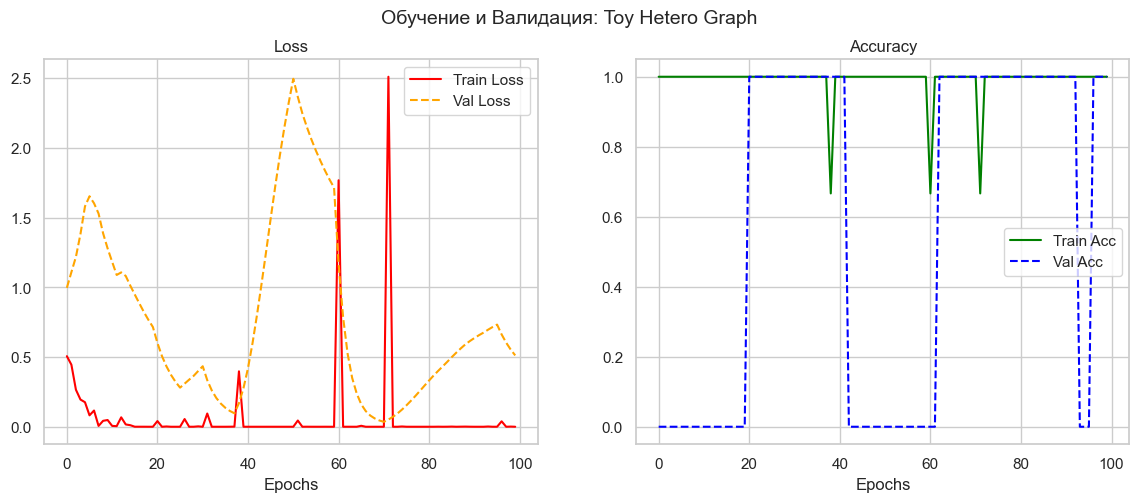

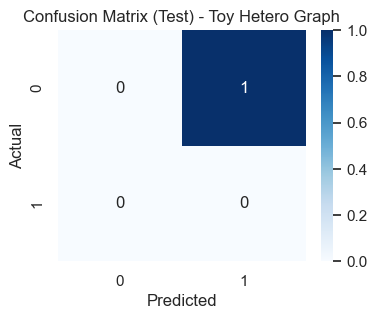

Ошибки модели на узлах (индексы): [4] ...

========== Запуск эксперимента: IMDB Hetero Graph ==========


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ HeteroSAGE │  1.6 M │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.6 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 38                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

`Trainer.fit` stopped: `max_epochs=100` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5575042963027954     │
└───────────────────────────┴───────────────────────────┘

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


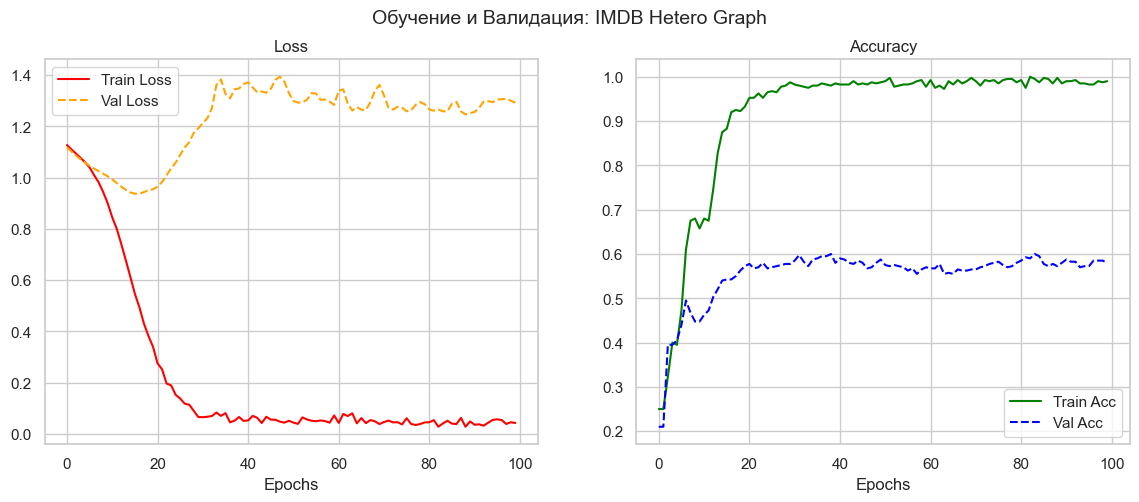

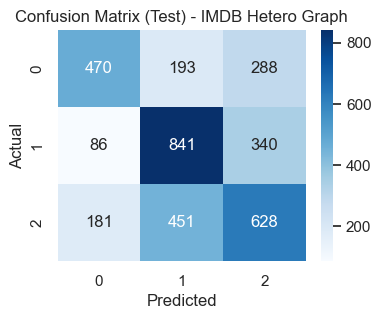

Ошибки модели на узлах (индексы): [1, 4, 5, 6, 11, 14, 16, 17, 18, 19] ...


LitHeteroNodeClassifier(
  (model): HeteroSAGE(
    (conv1): HeteroConv(num_relations=4)
    (conv2): HeteroConv(num_relations=4)
    (lin): Linear(64, 3, bias=True)
  )
)

In [25]:
class LitHeteroNodeClassifier(pl.LightningModule):
    def __init__(self, model: nn.Module, target_node: str, lr: float = 0.005, weight_decay: float = 5e-4):
        super().__init__()
        self.model = model
        self.target_node = target_node
        self.lr = lr
        self.weight_decay = weight_decay
        
        self.train_losses = []
        self.train_accs = []
        self.val_losses = []
        self.val_accs = []
        
    def forward(self, x_dict, edge_index_dict):
        return self.model(x_dict, edge_index_dict)

    def _compute_metrics(self, batch, mask_name: str) -> Tuple[torch.Tensor, torch.Tensor]:
        """Вспомогательная функция для расчета Loss и Accuracy по маске."""
        out = self(batch.x_dict, batch.edge_index_dict)
        mask = batch[self.target_node][mask_name]
        
        y = batch[self.target_node].y
        if y.dim() > 1 and y.shape[1] > 1:
            y = y.argmax(dim=-1)
            
        loss = F.cross_entropy(out[mask], y[mask])
        preds = out[mask].argmax(dim=-1)
        acc = accuracy_score(y[mask].cpu(), preds.cpu())
        
        return loss, torch.tensor(acc, dtype=torch.float32)

    def training_step(self, batch, batch_idx):
        batch_size = batch[self.target_node].train_mask.sum().item() 

        loss, acc = self._compute_metrics(batch, 'train_mask')
        self.log('train_loss', loss, prog_bar=True, batch_size=batch_size)
        self.log('train_acc', acc, prog_bar=True, batch_size=batch_size)
        
        self.train_losses.append(loss.item())
        self.train_accs.append(acc.item())
        return loss

    def validation_step(self, batch, batch_idx):
        if self.trainer.sanity_checking:
            return

        batch_size = batch[self.target_node].val_mask.sum().item()
        loss, acc = self._compute_metrics(batch, 'val_mask')
        self.log('val_loss', loss, prog_bar=True, batch_size=batch_size)
        self.log('val_acc', acc, prog_bar=True, batch_size=batch_size)

        self.val_losses.append(loss.item())
        self.val_accs.append(acc.item())

    def test_step(self, batch, batch_idx):
        batch_size = batch[self.target_node].test_mask.sum().item()
        loss, acc = self._compute_metrics(batch, 'test_mask')
        self.log('test_acc', acc, batch_size=batch_size)
        
        out = self(batch.x_dict, batch.edge_index_dict)
        mask = batch[self.target_node].test_mask
        y = batch[self.target_node].y
        if y.dim() > 1 and y.shape[1] > 1:
             y = y.argmax(dim=-1)
                
        preds = out[mask].argmax(dim=-1)
        true_labels = y[mask]
        
        cm = confusion_matrix(true_labels.cpu(), preds.cpu())
        
        global_indices = torch.arange(batch[self.target_node].num_nodes, device=mask.device)[mask]
        errors = global_indices[preds != true_labels]
        
        self.test_cm = cm
        self.test_errors = errors.cpu().tolist()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)


def run_experiment(data: HeteroData, target_node: str, hidden_dim: int = 64, epochs: int = 100, title: str = ""):
    """Функция для запуска пайплайна обучения и оценки."""
    print(f"\n========== Запуск эксперимента: {title} ==========")
    
    if data[target_node].y.dim() == 1:
        out_channels = len(torch.unique(data[target_node].y))
    else:
        out_channels = data[target_node].y.shape[1]
        
    model = HeteroSAGE(data.metadata(), hidden_channels=hidden_dim, out_channels=out_channels, target_node=target_node)
    
    with torch.no_grad():
        model(data.x_dict, data.edge_index_dict)
        
    lit_model = LitHeteroNodeClassifier(model, target_node=target_node, lr=0.005, weight_decay=5e-4)
    
    from torch_geometric.loader import DataLoader
    loader = DataLoader([data], batch_size=1)
    
    trainer = pl.Trainer(
        max_epochs=epochs,
        enable_progress_bar=True,
        logger=True,
        enable_checkpointing=False
    )
    
    trainer.fit(lit_model, train_dataloaders=loader, val_dataloaders=loader)
    trainer.test(lit_model, dataloaders=loader)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Обучение и Валидация: {title}', fontsize=14)
    
    ax1.plot(lit_model.train_losses, label='Train Loss', color='red')
    ax1.plot(lit_model.val_losses, label='Val Loss', color='orange', linestyle='--')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epochs')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(lit_model.train_accs, label='Train Acc', color='green')
    ax2.plot(lit_model.val_accs, label='Val Acc', color='blue', linestyle='--')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.legend()
    ax2.grid(True)
    
    plt.show()
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(lit_model.test_cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (Test) - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print(f"Ошибки модели на узлах (индексы): {lit_model.test_errors[:10]} ...")
    return lit_model


# Запускаем для Toy Data
run_experiment(toy_hetero, target_node='movie', epochs=100, title="Toy Hetero Graph")

# Запускаем для Real Data (IMDB)
run_experiment(real_hetero, target_node='movie', epochs=100, title="IMDB Hetero Graph")

<p class="task" id="6"></p>

6. Финальное задание (повышенной сложности): **мини-эксперимент по структуре графа**.

Проведите на **реальном** гетерогенном графе (`real_hetero`) серию прогонов с фиксированными гиперпараметрами, меняя одно из следующего (на выбор):

* **Абляция типа рёбер:** поочерёдно удалите один тип ребра из `edge_index_dict` (или замените его пустым индексом), остальное без изменений; либо
* **Ширина скрытого слоя:** 2–3 значения `hidden_channels`.

Зафиксируйте в таблице: что менялось, число параметров модели, финальная `test accuracy`, приблизительное время обучения. Сделайте 1–2 графика (например, test accuracy по вариантам). Сформулируйте вывод: какие типы рёбер (или какая ширина) наиболее влияют на качество и почему это может быть так с точки зрения семантики графа.

- [ ] Проверено на семинаре



=== Эксперимент: Удаление связей между director и movie ===
Будут удалены ребра: [('movie', 'to', 'director'), ('director', 'to', 'movie')]

========== Запуск эксперимента: Ablation: No director-movie ==========


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ HeteroSAGE │  1.6 M │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.6 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 38                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

`Trainer.fit` stopped: `max_epochs=100` reached.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.5623921751976013     │
└───────────────────────────┴───────────────────────────┘

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


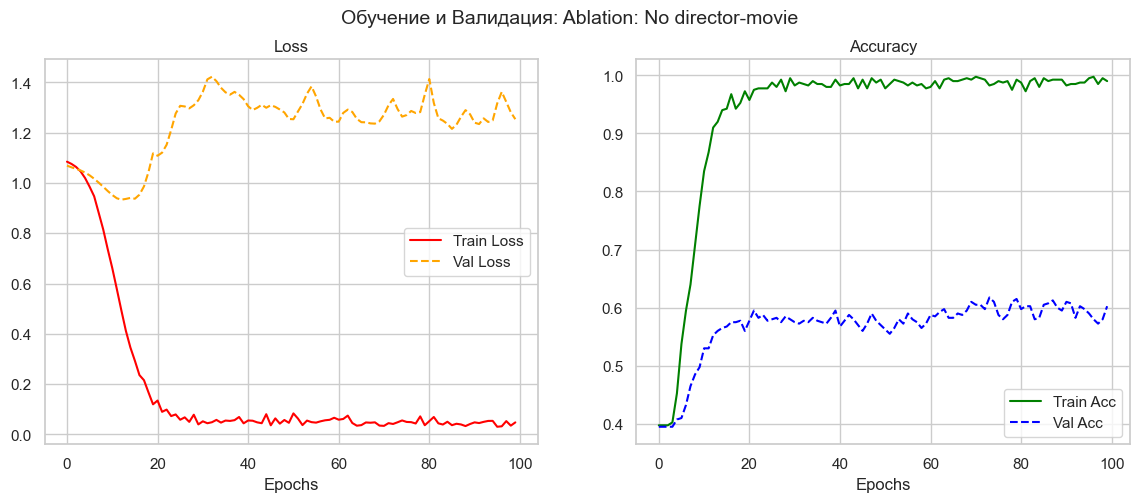

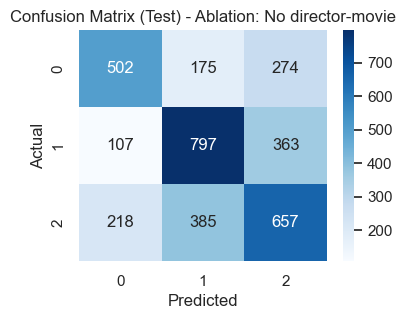

Ошибки модели на узлах (индексы): [1, 4, 5, 6, 11, 14, 17, 18, 19, 20] ...

--- Результаты абляции ---
Число параметров модели: 1603267
Время обучения (сек): 18.71


In [26]:
import copy
import time

def ablation_experiment(data: HeteroData, src_type: str, dst_type: str):
    import copy
    import time
    
    ablated_data = copy.deepcopy(data)
    
    keys_to_delete = [
        edge_type for edge_type in ablated_data.edge_types
        if (edge_type[0] == src_type and edge_type[2] == dst_type) or 
           (edge_type[0] == dst_type and edge_type[2] == src_type)
    ]
    
    print(f"\n=== Эксперимент: Удаление связей между {src_type} и {dst_type} ===")
    print(f"Будут удалены ребра: {keys_to_delete}")
    
    for k in keys_to_delete:
        del ablated_data.edge_index_dict[k]
        
    start_time = time.time()
    lit_model = run_experiment(ablated_data, target_node='movie', epochs=100, title=f"Ablation: No {src_type}-{dst_type}")
    elapsed = time.time() - start_time
    
    num_params = sum(p.numel() for p in lit_model.parameters() if p.requires_grad)
    
    print(f"\n--- Результаты абляции ---")
    print(f"Число параметров модели: {num_params}")
    print(f"Время обучения (сек): {elapsed:.2f}")



ablation_experiment(real_hetero, src_type='director', dst_type='movie')

Без director-to-movie связей модель обучилась лучше...

## Мини-чеклист перед сдачей

- [ ] Использованы оба графа: ручной `toy_hetero` и загруженный `real_hetero` из `torch_geometric.datasets`.
- [ ] Явно указаны целевой **тип узлов**, число классов и маски train/val/test только для него.
- [ ] Модель построена через `HeteroConv` (или эквивалент, согласованный с преподавателем) с двумя гетерогенными слоями.
- [ ] Финальный эксперимент (задание 6) выполнен на `real_hetero` с таблицей и выводом.
